# FlyRank Search Intelligence Capstone
## CTR Opportunity Scoring for Content Review

### Research Question

Which visible content pages appear to under-capture clicks relative to
similar pages, and should therefore be reviewed first?

This project builds a decision-support ranking system using observable Google
Search Console signals. The goal is not to prove that changing a page will
increase traffic. The goal is to prioritize pages for human review.

The project reuses the March 2026 workflow from earlier assignments:

- **ML-04** data contract (unit of analysis, feature / label / context split)
- **ML-07** transparent baseline (`HIGH_VOLUME_LOW_CTR` -> `REVIEW_CTR`)
- **ML-08** modeling lane (grouped validation, learned models, Precision@K)

It compares the transparent Week-4 baseline against machine-learning models
using the **same** target definition and the **same** client-grouped
validation design, then produces a ranked action queue with reason codes and
honest decision-support framing.

## 1. Data Contract

### Unit of analysis

One row is one pseudonymized content item (`client_hash_id` x
`content_hash_id`) aggregated over the decision window.

### Windows

- **Decision window:** March 2026 (`month=2026-03`). All model features are
  computed only from this window.
- **Outcome window:** April 2026 (`month=2026-04`). Used only to construct the
  label. It is never read into the feature matrix.

### Features (decision-time, March only)

- `impressions` - Google Search impressions (March sum)
- `clicks` - Google Search clicks (March sum)
- `ctr_pct` - clicks / impressions * 100 (March)
- `avg_position` - impression-time-weighted average search position (March)
- `observed_days` - number of days the item had GSC data in March
- `log_impressions` - `log1p(impressions)`
- `log_clicks` - `log1p(clicks)`
- `ctr_decimal` - `ctr_pct / 100`
- `position_inverse` - `1 / avg_position`

The engineered features are deterministic transforms of March observations,
so they are all known at the review decision moment.

### Label / proxy

`is_opportunity` = 1 when **both** hold:

1. March `ctr_pct` is below the median `ctr_pct` for the item's March
   average-position bucket (a visible low-CTR page), and
2. `ctr_pct` increased from March to April (an opportunity that was actually
   realised in the observed outcome window).

This matches the ML-08 target. It is a proxy for prioritization, not proof
that an edit caused the change. The label is kept strictly separate from the
features.

### Context (not features)

- `client_hash_id` - grouping key for the train/test split
- `content_hash_id` - identifier for ranking and review
- `first_report_date` / `last_report_date` - window checks

### Excluded information

- `trend_direction`, `trend_pct`, `is_declining_label` - label-derived
- every April / outcome field (`*_april`) - not known at the decision moment
- the ML-07 `qualifies` rule itself is **not** used as the target, so the
  learned model is not simply told to reproduce the baseline

### Limitation

The data can identify pages that *appear* to have a CTR opportunity. It cannot
prove that changing a title, snippet, or page body will cause more clicks.
Search intent, SERP features, and brand effects are not represented here.

In [5]:
!pip -q install duckdb pandas numpy scikit-learn matplotlib

In [6]:
# ============================================
# Imports and reproducibility
# ============================================

import json
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("Imports successful. Random seed:", RANDOM_STATE)

Imports successful. Random seed: 42


In [7]:
# ============================================
# Hugging Face authentication (Colab Secrets)
# ============================================

from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")

if not HF_TOKEN:
    raise RuntimeError(
        "HF_TOKEN was not found. Add a READ Hugging Face token "
        "to Colab Secrets with the name HF_TOKEN."
    )

print("HF token loaded.")

HF token loaded.


In [8]:
# ============================================
# DuckDB + Hugging Face connection
# ============================================

con = duckdb.connect()

con.execute("INSTALL httpfs;")
con.execute("LOAD httpfs;")

con.execute(
    f"""
    CREATE OR REPLACE SECRET hf (
        TYPE HUGGINGFACE,
        TOKEN '{HF_TOKEN}'
    )
    """
)

print("DuckDB + Hugging Face connection ready.")

DuckDB + Hugging Face connection ready.


In [9]:
# ============================================
# Warehouse partitions
# ============================================

MARCH = (
    "hf://datasets/FlyRank/internship-warehouse/"
    "fact_content_daily_performance/month=2026-03/data_0.parquet"
)

APRIL = (
    "hf://datasets/FlyRank/internship-warehouse/"
    "fact_content_daily_performance/month=2026-04/data_0.parquet"
)

print("Decision window :", MARCH)
print("Outcome window  :", APRIL)

Decision window : hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/data_0.parquet
Outcome window  : hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-04/data_0.parquet


## 2. Load and Aggregate the Data

The warehouse table has a daily grain
(`report_date` x `client_hash_id` x `content_hash_id`). For this capstone the
March observations are aggregated to one row per client-content item, using
the same SQL as ML-07 and ML-08.

Only rows with `gsc_data_available IS TRUE` are included, so unavailable
measurements are not silently treated as real zeros.

In [10]:
# ============================================
# March decision-window content table
# ============================================

march = con.sql(f"""
WITH daily AS (
    SELECT
        client_hash_id,
        content_hash_id,
        report_date,
        gsc_impressions,
        gsc_clicks,
        gsc_avg_position,
        gsc_data_available
    FROM read_parquet('{MARCH}')
    WHERE gsc_data_available IS TRUE
),

content_month AS (
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(gsc_impressions) AS impressions,
        SUM(gsc_clicks) AS clicks,

        CASE
            WHEN SUM(gsc_impressions) > 0
            THEN SUM(gsc_clicks) * 100.0 / SUM(gsc_impressions)
            ELSE NULL
        END AS ctr_pct,

        AVG(
            CASE WHEN gsc_avg_position > 0 THEN gsc_avg_position ELSE NULL END
        ) AS avg_position,

        COUNT(*) AS observed_days,
        MIN(report_date) AS first_report_date,
        MAX(report_date) AS last_report_date

    FROM daily
    GROUP BY client_hash_id, content_hash_id
)

SELECT *
FROM content_month
WHERE impressions > 0
  AND ctr_pct IS NOT NULL
  AND avg_position IS NOT NULL
  AND avg_position > 0
""").df()

print(f"Usable March content items: {len(march):,}")
display(march.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Usable March content items: 175,304


,client_hash_id,content_hash_id,impressions,clicks,ctr_pct,avg_position,observed_days,first_report_date,last_report_date
0,client_73cda7b4e4f265ea,content_7a105f548d9c6916,6523.0,7.0,0.107313,7.209549,31,2026-03-01,2026-03-31
1,client_73cda7b4e4f265ea,content_a3ea9792f793ec72,453.0,0.0,0.000000,3.307255,31,2026-03-01,2026-03-31
2,client_73cda7b4e4f265ea,content_36c36abc7650d7af,5630.0,6.0,0.106572,6.724039,31,2026-03-01,2026-03-31
3,client_73cda7b4e4f265ea,content_a7da352b73b02668,4944.0,13.0,0.262945,7.244844,31,2026-03-01,2026-03-31
4,client_73cda7b4e4f265ea,content_1855a661b4d36130,429.0,1.0,0.233100,4.499519,31,2026-03-01,2026-03-31


In [11]:
# ============================================
# March data summary
# ============================================

print("Rows          :", f"{len(march):,}")
print("Clients       :", f"{march['client_hash_id'].nunique():,}")
print("Content items :", f"{march['content_hash_id'].nunique():,}")

print("\nDate range:")
print(march["first_report_date"].min(), "to", march["last_report_date"].max())

print("\nCTR (%) summary:")
display(march["ctr_pct"].describe())

print("\nImpressions summary:")
display(march["impressions"].describe())

Rows          : 175,304
Clients       : 47
Content items : 175,304

Date range:
2026-03-01 00:00:00 to 2026-03-31 00:00:00

CTR (%) summary:


,ctr_pct
count,175304.000000
mean,0.436343
std,3.451047
min,0.000000
25%,0.000000
50%,0.000000
75%,0.218341
max,100.000000



Impressions summary:


,impressions
count,175304.000000
mean,1600.961946
std,5451.604207
min,1.000000
25%,21.000000
50%,178.000000
75%,1053.000000
max,617124.000000


In [12]:
# ============================================
# Missing-value check
# ============================================

display(march.isna().sum().to_frame("missing_count"))

,missing_count
client_hash_id,0
content_hash_id,0
impressions,0
clicks,0
ctr_pct,0
avg_position,0
observed_days,0
first_report_date,0
last_report_date,0


## 3. Signal Audit

Two signals underpin the baseline and the label.

**Signal 1 - CTR vs. average position.** Comparing raw CTR across all
positions is misleading: a page in position 1-3 naturally earns a different
CTR than one in position 21-50. CTR is therefore read *relative to a
position-tier benchmark*.

**Signal 2 - search impression volume.** A CTR gap on a high-impression page
puts more observed clicks at stake, which is why volume is used as a
prioritization signal (not a causal claim).

The verdicts below must be recorded from the executed tables, not written in
advance.

In [13]:
# ============================================
# Signal 1 - CTR by average-position bucket
# ============================================

march["position_bucket"] = pd.cut(
    march["avg_position"],
    bins=[0, 3, 10, 20, 50, float("inf")],
    labels=["1-3", "4-10", "11-20", "21-50", "51+"],
)

position_summary = (
    march
    .groupby("position_bucket", observed=False)
    .agg(
        n=("content_hash_id", "size"),
        median_ctr_pct=("ctr_pct", "median"),
        mean_ctr_pct=("ctr_pct", "mean"),
        median_position=("avg_position", "median"),
        median_impressions=("impressions", "median"),
    )
    .reset_index()
)

display(position_summary)

,position_bucket,n,median_ctr_pct,mean_ctr_pct,median_position,median_impressions
0,1-3,13136,0.096246,1.100994,2.278532,654.0
1,4-10,81619,0.000000,0.514867,6.170215,204.0
2,11-20,32548,0.000000,0.330347,13.954362,256.0
3,21-50,34783,0.000000,0.228864,29.847951,165.0
4,51+,13218,0.000000,0.097918,64.964136,45.0


In [14]:
# ============================================
# Signal 2 - CTR by impression-volume quartile
# ============================================

volume_data = march.copy()
volume_data["volume_bucket"] = pd.qcut(
    volume_data["impressions"],
    q=4,
    labels=["Q1 - Lowest", "Q2", "Q3", "Q4 - Highest"],
    duplicates="drop",
)

volume_summary = (
    volume_data
    .groupby("volume_bucket", observed=False)
    .agg(
        n=("content_hash_id", "size"),
        median_impressions=("impressions", "median"),
        median_ctr_pct=("ctr_pct", "median"),
        mean_ctr_pct=("ctr_pct", "mean"),
    )
    .reset_index()
)

display(volume_summary)

impression_threshold = march["impressions"].median()
print("Median March impression threshold:", f"{impression_threshold:,.2f}")

,volume_bucket,n,median_impressions,median_ctr_pct,mean_ctr_pct
0,Q1 - Lowest,44350,5.0,0.000000,0.926481
1,Q2,43321,69.0,0.000000,0.277652
2,Q3,43810,427.0,0.000000,0.238019
3,Q4 - Highest,43823,3042.0,0.194951,0.295447


Median March impression threshold: 178.00


### Signal verdicts

Read from the executed tables in section 3.

**Signal 1 — Position and CTR: CONFIRMED.**
Mean CTR falls monotonically as position worsens: 1.10% (tier 1-3), 0.51%
(4-10), 0.33% (11-20), 0.23% (21-50), 0.10% (51+), across
13,136 / 81,619 / 32,548 / 34,783 / 13,218 pages. Median CTR is 0.10% in tier
1-3 and 0.00% in every worse tier, because most pages record no clicks in a
single month. That degeneracy is exactly why the label and the baseline
compare a page against its own position tier rather than against one global
CTR number.

**Signal 2 — Search volume: MIXED.**
By impression quartile (n ≈ 44k each), only the top quartile has a non-zero
median CTR (0.19% vs 0.00% for Q1-Q3), so higher-volume pages are where a CTR
gap can even be measured — useful for prioritisation. But mean CTR does not
rise with volume; it is actually highest in the lowest-volume quartile
(0.93%), driven by a few tiny-impression pages with one lucky click. Volume is
therefore kept as a prioritisation filter, not as evidence that more
impressions produce a higher CTR.

## 4. Feature Engineering

The model uses nine decision-time features, all derived from the March
window:

| Feature | Why it is known at the decision moment |
| --- | --- |
| `impressions` | observed March search impressions |
| `clicks` | observed March search clicks |
| `ctr_pct` | observed March clicks / impressions |
| `avg_position` | observed March average search position |
| `observed_days` | count of March days with GSC data |
| `log_impressions` | `log1p` of an observed value |
| `log_clicks` | `log1p` of an observed value |
| `ctr_decimal` | rescaled observed CTR |
| `position_inverse` | `1 / avg_position`, an observed value |

No April field and no label-derived field is used as a feature.

In [15]:
# ============================================
# Decision-time feature engineering
# ============================================

march["log_impressions"] = np.log1p(march["impressions"])
march["log_clicks"] = np.log1p(march["clicks"])
march["ctr_decimal"] = march["ctr_pct"] / 100.0
march["position_inverse"] = 1.0 / march["avg_position"]

display(
    march[[
        "impressions", "clicks", "ctr_pct", "avg_position", "observed_days",
        "log_impressions", "log_clicks", "ctr_decimal", "position_inverse",
    ]].head()
)

,impressions,clicks,ctr_pct,avg_position,observed_days,log_impressions,log_clicks,ctr_decimal,position_inverse
0,6523.0,7.0,0.107313,7.209549,31,8.783243,2.079442,0.001073,0.138705
1,453.0,0.0,0.000000,3.307255,31,6.118097,0.000000,0.000000,0.302366
2,5630.0,6.0,0.106572,6.724039,31,8.636042,1.945910,0.001066,0.148720
3,4944.0,13.0,0.262945,7.244844,31,8.506132,2.639057,0.002629,0.138029
4,429.0,1.0,0.233100,4.499519,31,6.063785,0.693147,0.002331,0.222246


## 5. Define the Modeling Target

The target is the ML-08 `is_opportunity` label, so the baseline, the model,
and the ranked queue all form one reproducible workflow.

A page is a positive (`is_opportunity = 1`) when **both**:

1. `march_low_ctr` - its March `ctr_pct` is below the median `ctr_pct` for its
   March position bucket, and
2. `ctr_improved` - its `ctr_pct` rose from March to April.

Condition 1 is the visible opportunity; condition 2 is the observed outcome
that the opportunity was real. This is a prioritization proxy, not proof that
an optimization produced the gain. The ML-07 rule is deliberately not the
target.

In [16]:
# ============================================
# April outcome-window content table
# ============================================

april = con.sql(f"""
WITH daily AS (
    SELECT
        client_hash_id,
        content_hash_id,
        report_date,
        gsc_impressions,
        gsc_clicks,
        gsc_avg_position,
        gsc_data_available
    FROM read_parquet('{APRIL}')
    WHERE gsc_data_available IS TRUE
),

content_month AS (
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(gsc_impressions) AS impressions_april,
        SUM(gsc_clicks) AS clicks_april,

        CASE
            WHEN SUM(gsc_impressions) > 0
            THEN SUM(gsc_clicks) * 100.0 / SUM(gsc_impressions)
            ELSE NULL
        END AS ctr_april_pct,

        AVG(
            CASE WHEN gsc_avg_position > 0 THEN gsc_avg_position ELSE NULL END
        ) AS avg_position_april,

        COUNT(*) AS observed_days_april

    FROM daily
    GROUP BY client_hash_id, content_hash_id
)

SELECT *
FROM content_month
WHERE impressions_april > 0
  AND ctr_april_pct IS NOT NULL
""").df()

print(f"Usable April content items: {len(april):,}")
display(april.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Usable April content items: 194,760


,client_hash_id,content_hash_id,impressions_april,clicks_april,ctr_april_pct,avg_position_april,observed_days_april
0,client_62f4a7e64f5e0096,content_143987cfdeaba4c0,187.0,0.0,0.00000,45.258636,28
1,client_62f4a7e64f5e0096,content_13a8105125458098,23.0,0.0,0.00000,5.083333,14
2,client_62f4a7e64f5e0096,content_e2bd76be7eed690d,17.0,0.0,0.00000,7.203704,12
3,client_62f4a7e64f5e0096,content_86ab16840c4e0e1a,202.0,1.0,0.49505,11.203296,29
4,client_62f4a7e64f5e0096,content_3f87f49c36774e23,93.0,0.0,0.00000,26.178667,27


In [17]:
# ============================================
# Build the is_opportunity label
# ============================================

march_position_medians = (
    march.groupby("position_bucket", observed=False)["ctr_pct"].median()
)

march_target = march.copy()
march_target["position_bucket_median_ctr"] = (
    march_target["position_bucket"].map(march_position_medians)
)

model_df = march_target.merge(
    april[[
        "client_hash_id", "content_hash_id",
        "impressions_april", "clicks_april", "ctr_april_pct",
        "avg_position_april", "observed_days_april",
    ]],
    on=["client_hash_id", "content_hash_id"],
    how="inner",
)

model_df["march_low_ctr"] = (
    model_df["ctr_pct"] < model_df["position_bucket_median_ctr"]
)
model_df["ctr_improved"] = (
    model_df["ctr_april_pct"] > model_df["ctr_pct"]
)
model_df["is_opportunity"] = (
    model_df["march_low_ctr"] & model_df["ctr_improved"]
).astype(int)

print("March pages with an observed April outcome:", f"{len(model_df):,}")
print("\nTarget distribution:")
display(model_df["is_opportunity"].value_counts())
print("\nObserved positive rate:", round(model_df["is_opportunity"].mean(), 4))

March pages with an observed April outcome: 157,790

Target distribution:


,count
is_opportunity,
0,156717
1,1073



Observed positive rate: 0.0068


In [18]:
# ============================================
# Target sanity check
# ============================================

target_summary = (
    model_df
    .groupby("is_opportunity")
    .agg(
        rows=("content_hash_id", "size"),
        median_march_ctr=("ctr_pct", "median"),
        median_april_ctr=("ctr_april_pct", "median"),
        median_march_impressions=("impressions", "median"),
        median_april_impressions=("impressions_april", "median"),
    )
    .reset_index()
)

display(target_summary)

,is_opportunity,rows,median_march_ctr,median_april_ctr,median_march_impressions,median_april_impressions
0,0,156717,0.0,0.000000,249.0,199.0
1,1,1073,0.0,0.225749,817.0,1054.0


## 6. Transparent Baseline (ML-07)

The Week-4 baseline prioritizes a page when **both**:

- `impressions >= ` the median March impression volume, and
- `ctr_pct <` the median CTR for its average-position bucket.

| Field | Value |
| --- | --- |
| Reason code | `HIGH_VOLUME_LOW_CTR` |
| Action | `REVIEW_CTR` |

It is intentionally simple and fully explainable, and it is evaluated on the
exact same held-out test rows as the learned models.

In [19]:
# ============================================
# Reproduce the ML-07 baseline on model_df
# ============================================

impression_threshold = march["impressions"].median()

model_df["baseline_prediction"] = (
    (model_df["impressions"] >= impression_threshold)
    & (model_df["ctr_pct"] < model_df["position_bucket_median_ctr"])
).astype(int)

model_df["ctr_gap_pct"] = (
    model_df["position_bucket_median_ctr"] - model_df["ctr_pct"]
).clip(lower=0)

print("ML-07 impression threshold :", f"{impression_threshold:,.2f}")
print("Baseline positives (full)  :", int(model_df["baseline_prediction"].sum()))

ML-07 impression threshold : 178.00
Baseline positives (full)  : 1850


## 7. Validation Design

A `GroupShuffleSplit` (test_size 0.20, `random_state=42`) grouped by
`client_hash_id` keeps every client entirely in train or entirely in test.
Pages from one client share templates and search patterns, so a random row
split would leak that structure and make the test look easier than it is.

`client_hash_id` is used only for grouping. It is not a feature.

In [20]:
# ============================================
# Feature matrix + grouped train/test split
# ============================================

FEATURE_COLUMNS = [
    "impressions",
    "clicks",
    "ctr_pct",
    "avg_position",
    "observed_days",
    "log_impressions",
    "log_clicks",
    "ctr_decimal",
    "position_inverse",
]

required = FEATURE_COLUMNS + ["is_opportunity", "client_hash_id",
                              "baseline_prediction", "ctr_gap_pct",
                              "position_bucket_median_ctr"]

model_data = model_df.dropna(subset=required).reset_index(drop=True)

X = model_data[FEATURE_COLUMNS]
y = model_data["is_opportunity"].astype(int)
groups = model_data["client_hash_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train, groups_test = groups.iloc[train_idx], groups.iloc[test_idx]

print("Training rows :", f"{len(X_train):,}")
print("Test rows     :", f"{len(X_test):,}")
print("Train positive rate :", round(y_train.mean(), 4))
print("Test positive rate  :", round(y_test.mean(), 4))

Training rows : 136,739
Test rows     : 21,051
Train positive rate : 0.0072
Test positive rate  : 0.0041


In [21]:
# ============================================
# Verify client separation
# ============================================

overlap = set(groups_train).intersection(set(groups_test))
print("Train clients :", len(set(groups_train)))
print("Test clients  :", len(set(groups_test)))
print("Client overlap:", len(overlap))

assert len(overlap) == 0
print("Client separation check: PASSED")

Train clients : 36
Test clients  : 10
Client overlap: 0
Client separation check: PASSED


## 8. Models

Two learned models, chosen for contrast, not for assumed superiority:

- **Logistic Regression** - interpretable linear baseline (median imputation,
  standardized features, `class_weight="balanced"`).
- **Random Forest** - nonlinear alternative that can capture interactions
  (median imputation, `class_weight="balanced"`).

The final choice is made from the measured Precision@K against the ML-07
baseline in section 9.

In [22]:
# ============================================
# Logistic Regression
# ============================================

logistic_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )),
])

logistic_model.fit(X_train, y_train)
lr_scores = logistic_model.predict_proba(X_test)[:, 1]
print("Logistic Regression trained.")

Logistic Regression trained.


In [23]:
# ============================================
# Random Forest
# ============================================

rf_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

rf_model.fit(X_train, y_train)
rf_scores = rf_model.predict_proba(X_test)[:, 1]
print("Random Forest trained.")

Random Forest trained.


## 9. Primary Metric - Precision@K

The operational question is *which pages to review first*, so the primary
metric is **Precision@K** (K = 10, 20, 50; primary K = 50): of the top-K
pages a method prioritizes, how many are actual opportunities.

Threshold metrics (accuracy, precision, recall, F1, ROC-AUC, average
precision) are reported as secondary context only. With a positive rate near
1%, accuracy is dominated by the negative class and is not the decision
metric.

In [24]:
# ============================================
# Precision@K helper
# ============================================

def precision_at_k(y_true, scores, k):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)
    k = min(k, len(y_true))
    order = np.argsort(scores)[::-1][:k]
    return float(y_true[order].mean())

K_VALUES = [10, 20, 50]
PRIMARY_K = 50
PRIMARY_METRIC = f"Precision@{PRIMARY_K}"
print("Primary metric:", PRIMARY_METRIC)

Primary metric: Precision@50


In [25]:
# ============================================
# ML-07 baseline scores on the SAME test rows
# ============================================

baseline_scores = model_data.iloc[test_idx]["baseline_prediction"].to_numpy()
print("Baseline positive predictions on test:", int(baseline_scores.sum()))

Baseline positive predictions on test: 171


In [26]:
# ============================================
# Precision@K comparison
# ============================================

methods = {
    "ML-07 Baseline": baseline_scores,
    "Logistic Regression": lr_scores,
    "Random Forest": rf_scores,
}

rows = []
for name, scores in methods.items():
    row = {"Model": name}
    for k in K_VALUES:
        row[f"Precision@{k}"] = precision_at_k(y_test, scores, k)
    rows.append(row)

comparison_df = pd.DataFrame(rows)
display(comparison_df)

,Model,Precision@10,Precision@20,Precision@50
0,ML-07 Baseline,0.6,0.55,0.40
1,Logistic Regression,0.6,0.40,0.32
2,Random Forest,0.1,0.15,0.22


In [27]:
# ============================================
# Secondary threshold metrics (context only)
# ============================================

def threshold_metrics(name, y_true, scores):
    pred = (np.asarray(scores) >= 0.5).astype(int)
    two_class = len(np.unique(y_true)) > 1
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, pred),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "Recall": recall_score(y_true, pred, zero_division=0),
        "F1": f1_score(y_true, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, scores) if two_class else np.nan,
        "AvgPrecision": average_precision_score(y_true, scores) if two_class else np.nan,
    }

secondary_df = pd.DataFrame([
    threshold_metrics("ML-07 Baseline", y_test, baseline_scores),
    threshold_metrics("Logistic Regression", y_test, lr_scores),
    threshold_metrics("Random Forest", y_test, rf_scores),
])

display(secondary_df)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,AvgPrecision
0,ML-07 Baseline,0.993302,0.339181,0.674419,0.451362,0.834514,0.230080
1,Logistic Regression,0.972733,0.130303,1.000000,0.230563,0.994073,0.351806
2,Random Forest,0.994442,0.333333,0.360465,0.346369,0.989692,0.295242


In [28]:
# ============================================
# Select the best learned model by Precision@50
# ============================================

learned = comparison_df[comparison_df["Model"] != "ML-07 Baseline"]
best_row = learned.loc[learned[PRIMARY_METRIC].idxmax()]
best_model_name = best_row["Model"]

baseline_primary = comparison_df.loc[
    comparison_df["Model"] == "ML-07 Baseline", PRIMARY_METRIC
].iloc[0]
best_primary = best_row[PRIMARY_METRIC]

selected_model, selected_scores = (
    (rf_model, rf_scores) if best_model_name == "Random Forest"
    else (logistic_model, lr_scores)
)

print("Best learned model     :", best_model_name)
print(f"Baseline {PRIMARY_METRIC} :", round(baseline_primary, 4))
print(f"Best {PRIMARY_METRIC}     :", round(best_primary, 4))
print("Absolute improvement   :", round(best_primary - baseline_primary, 4))

Best learned model     : Logistic Regression
Baseline Precision@50 : 0.4
Best Precision@50     : 0.32
Absolute improvement   : -0.08


In [29]:
# ============================================
# Save model comparison results
# ============================================

output_dir = Path("work/outputs")
output_dir.mkdir(parents=True, exist_ok=True)

results_payload = {
    "primary_metric": PRIMARY_METRIC,
    "best_learned_model": best_model_name,
    "precision_at_k": comparison_df.to_dict(orient="records"),
    "secondary_threshold_metrics": secondary_df.to_dict(orient="records"),
    "train_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "train_positive_rate": float(round(y_train.mean(), 6)),
    "test_positive_rate": float(round(y_test.mean(), 6)),
}

results_file = output_dir / "capstone_model_results.json"
results_file.write_text(json.dumps(results_payload, indent=2, default=float))
print("Saved:", results_file)

Saved: work/outputs/capstone_model_results.json


## 10. Model Interpretation

Random Forest feature importance shows which observable signals the model
leaned on inside this dataset and split. It indicates use, not causation: a
high-importance feature is not proof that changing it changes CTR.

,importance
position_inverse,0.427880
avg_position,0.393170
ctr_decimal,0.067151
ctr_pct,0.060498
log_impressions,0.016649
impressions,0.015755
observed_days,0.013268
clicks,0.003102
log_clicks,0.002528


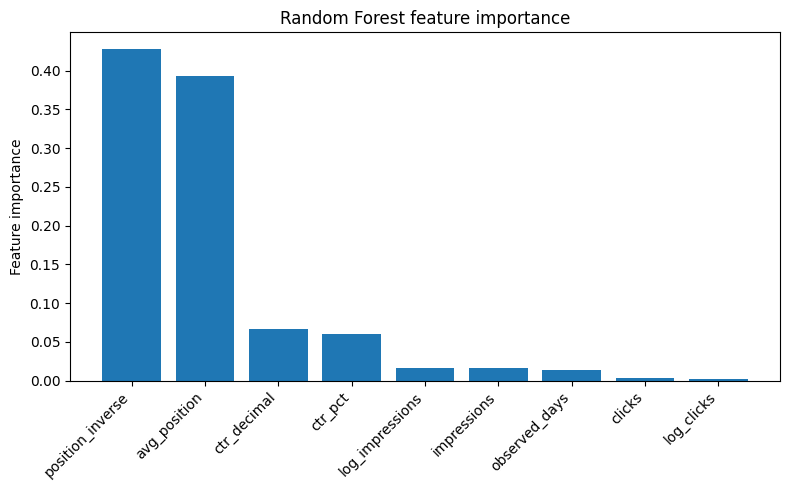

In [30]:
# ============================================
# Random Forest feature importance
# ============================================

rf_importance = (
    pd.Series(
        rf_model.named_steps["model"].feature_importances_,
        index=FEATURE_COLUMNS,
    )
    .sort_values(ascending=False)
)

display(rf_importance.to_frame("importance"))

plt.figure(figsize=(8, 5))
plt.bar(rf_importance.index, rf_importance.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Feature importance")
plt.title("Random Forest feature importance")
plt.tight_layout()
plt.show()

## 11. Error Analysis

Errors are inspected on the held-out test set, using the selected model at a
0.5 probability threshold (a coarse cut - Precision@K remains the decision
metric).

- A **false positive** may be a page whose low CTR is actually appropriate for
  its query mix or SERP, or whose CTR simply did not rise in April.
- A **false negative** may be a real opportunity that the March position and
  volume features do not capture.

In [31]:
# ============================================
# Confusion matrix + classification report
# ============================================

selected_pred = (selected_scores >= 0.5).astype(int)

print("Selected model:", best_model_name)
print("\nConfusion matrix [rows = actual 0/1, cols = predicted 0/1]:")
print(confusion_matrix(y_test, selected_pred))

print("\nClassification report:")
print(classification_report(y_test, selected_pred, digits=3, zero_division=0))

Selected model: Logistic Regression

Confusion matrix [rows = actual 0/1, cols = predicted 0/1]:
[[20391   574]
 [    0    86]]

Classification report:
              precision    recall  f1-score   support

           0      1.000     0.973     0.986     20965
           1      0.130     1.000     0.231        86

    accuracy                          0.973     21051
   macro avg      0.565     0.986     0.608     21051
weighted avg      0.996     0.973     0.983     21051



In [32]:
# ============================================
# Inspect false positives
# ============================================

error_df = model_data.iloc[test_idx].copy()
error_df["actual"] = y_test.to_numpy()
error_df["prediction"] = selected_pred
error_df["model_score"] = selected_scores

cols = [
    "content_hash_id", "impressions", "clicks", "ctr_pct", "avg_position",
    "position_bucket", "ctr_gap_pct", "ctr_april_pct", "model_score",
]

false_positives = error_df[
    (error_df["actual"] == 0) & (error_df["prediction"] == 1)
].sort_values("model_score", ascending=False)

print("False positives:", len(false_positives))
display(false_positives[cols].head(10))

False positives: 574


,content_hash_id,impressions,clicks,ctr_pct,avg_position,position_bucket,ctr_gap_pct,ctr_april_pct,model_score
38207,content_cdd93c30b9b06461,1347.0,0.0,0.000000,1.168339,1-3,0.096246,0.000000,0.998458
87951,content_8a29eeec466137f9,77.0,0.0,0.000000,0.588790,1-3,0.096246,0.000000,0.998456
119314,content_7aab39ab2c4b35e1,384.0,0.0,0.000000,1.535554,1-3,0.096246,0.000000,0.998270
23300,content_335cb77b9794b587,22112.0,4.0,0.018090,3.290033,4-10,0.000000,0.016621,0.998239
130795,content_2e7bb6f983d3e1b8,134.0,0.0,0.000000,1.181029,1-3,0.096246,0.000000,0.998161
67157,content_0de4e5c9d8133761,334.0,0.0,0.000000,0.998321,1-3,0.096246,0.000000,0.998136
88236,content_1bc8782404e3b132,5792.0,0.0,0.000000,2.339752,1-3,0.096246,0.000000,0.998105
57438,content_eac0a973f63c8b0d,252.0,0.0,0.000000,0.772549,1-3,0.096246,0.000000,0.998104
68311,content_5b9f20eb3b7f872b,17617.0,2.0,0.011353,3.815851,4-10,0.000000,0.027666,0.998005
40409,content_7ce972cc9107a9c9,845.0,0.0,0.000000,1.155798,1-3,0.096246,0.000000,0.997652


In [33]:
# ============================================
# Inspect false negatives
# ============================================

false_negatives = error_df[
    (error_df["actual"] == 1) & (error_df["prediction"] == 0)
].sort_values("model_score")

print("False negatives:", len(false_negatives))
display(false_negatives[cols].head(10))

False negatives: 0


,content_hash_id,impressions,clicks,ctr_pct,avg_position,position_bucket,ctr_gap_pct,ctr_april_pct,model_score


## 12. Final Ranked Recommendation Queue

The queue scores the full modeled population. The final score blends:

- `model_probability` from the selected model (weight 0.70), and
- the normalized observed CTR gap below the position-tier benchmark
  (weight 0.30).

A higher score means *review this page earlier*. It is not a prediction that
an edit will lift traffic.

In [34]:
# ============================================
# Score the full population
# ============================================

final_data = model_data.copy()
final_data["model_probability"] = selected_model.predict_proba(
    final_data[FEATURE_COLUMNS]
)[:, 1]

gap = final_data["ctr_gap_pct"].clip(lower=0)
max_gap = gap.max()
final_data["normalized_ctr_gap"] = gap / max_gap if max_gap > 0 else 0.0

final_data["final_score"] = 100.0 * (
    0.70 * final_data["model_probability"]
    + 0.30 * final_data["normalized_ctr_gap"]
)

final_data = final_data.sort_values("final_score", ascending=False).reset_index(drop=True)
final_data["rank"] = np.arange(1, len(final_data) + 1)

print("Scored rows:", f"{len(final_data):,}")

Scored rows: 157,790


In [35]:
# ============================================
# Reason codes and actions
# ============================================

def assign_reason_code(row):
    if (row["impressions"] >= impression_threshold
            and row["ctr_pct"] < row["position_bucket_median_ctr"]):
        return "HIGH_VOLUME_LOW_CTR"
    if row["ctr_gap_pct"] > 0:
        return "BELOW_POSITION_BENCHMARK"
    return "MONITOR"

def assign_action(row):
    return "REVIEW_CTR" if row["final_score"] >= 50 else "MONITOR"

final_data["reason_code"] = final_data.apply(assign_reason_code, axis=1)
final_data["action"] = final_data.apply(assign_action, axis=1)

display(
    final_data[[
        "rank", "content_hash_id", "impressions", "clicks", "ctr_pct",
        "avg_position", "position_bucket", "ctr_gap_pct", "model_probability",
        "final_score", "reason_code", "action",
    ]].head(20)
)

print("\nReason code counts:")
display(final_data["reason_code"].value_counts())
print("Action counts:")
display(final_data["action"].value_counts())

,rank,content_hash_id,impressions,clicks,ctr_pct,avg_position,position_bucket,ctr_gap_pct,model_probability,final_score,reason_code,action
0,1,content_fa17add7836d36c3,12588.0,0.0,0.0,1.902457,1-3,0.096246,0.999916,99.994114,HIGH_VOLUME_LOW_CTR,REVIEW_CTR
1,2,content_83167156f76e33e5,6827.0,0.0,0.0,1.136714,1-3,0.096246,0.999892,99.992453,HIGH_VOLUME_LOW_CTR,REVIEW_CTR
2,3,content_505a6318f1f5a53f,3512.0,0.0,0.0,1.243812,1-3,0.096246,0.999850,99.989468,HIGH_VOLUME_LOW_CTR,REVIEW_CTR
3,4,content_ecc27d32010b18e0,3900.0,0.0,0.0,0.573634,1-3,0.096246,0.999815,99.987025,HIGH_VOLUME_LOW_CTR,REVIEW_CTR
4,5,content_d397987113cb84a0,9887.0,0.0,0.0,1.953104,1-3,0.096246,0.999786,99.985009,HIGH_VOLUME_LOW_CTR,REVIEW_CTR
5,6,content_bc70bdc12eb6657c,2874.0,0.0,0.0,0.959949,1-3,0.096246,0.999782,99.984758,HIGH_VOLUME_LOW_CTR,REVIEW_CTR
6,7,content_db01d94616cdb80d,4202.0,0.0,0.0,0.911944,1-3,0.096246,0.999760,99.983235,HIGH_VOLUME_LOW_CTR,REVIEW_CTR
7,8,content_48353a0ccb387d98,3795.0,0.0,0.0,0.844471,1-3,0.096246,0.999738,99.981666,HIGH_VOLUME_LOW_CTR,REVIEW_CTR
8,9,content_df9174c05c7b0cbe,2028.0,0.0,0.0,0.766005,1-3,0.096246,0.999727,99.980909,HIGH_VOLUME_LOW_CTR,REVIEW_CTR
9,10,content_6194fb8b862a6c3a,2418.0,0.0,0.0,0.512791,1-3,0.096246,0.999716,99.980122,HIGH_VOLUME_LOW_CTR,REVIEW_CTR



Reason code counts:


,count
reason_code,
MONITOR,153342
BELOW_POSITION_BENCHMARK,2598
HIGH_VOLUME_LOW_CTR,1850


Action counts:


,count
action,
MONITOR,151467
REVIEW_CTR,6323


In [36]:
# ============================================
# Save the ranked recommendations
# ============================================

recommendation_columns = [
    "rank", "client_hash_id", "content_hash_id", "impressions", "clicks",
    "ctr_pct", "avg_position", "position_bucket", "ctr_gap_pct",
    "model_probability", "final_score", "reason_code", "action",
]

recommendations_file = output_dir / "capstone_ranked_recommendations.csv"
final_data[recommendation_columns].to_csv(recommendations_file, index=False)

print("Saved:", recommendations_file)
print("Rows written:", f"{len(final_data):,}")

Saved: work/outputs/capstone_ranked_recommendations.csv
Rows written: 157,790


## 13. Top-20 Review

For each of the top 20 candidates:

- **Action** - what a reviewer should investigate.
- **Reason code** - why the page was prioritized.
- **Confidence** - from the model probability and the observed CTR gap.
- **What could make it wrong** - query intent, SERP features, brand terms, or
  other factors not in the feature set may already explain the CTR.

In [37]:
# ============================================
# Top-20 review table
# ============================================

top20 = final_data.head(20).copy()

top20["confidence_note"] = np.where(
    top20["model_probability"] >= 0.70,
    "Higher: model probability and observed CTR gap both point to an opportunity.",
    "Moderate: worth a review, but the observable signals are not proof.",
)

top20["what_would_make_it_wrong"] = (
    "Low CTR may be appropriate for the query intent, SERP features, brand "
    "terms, or the page's actual search position; volume alone is not an "
    "optimization opportunity."
)

display(
    top20[[
        "rank", "content_hash_id", "action", "reason_code", "final_score",
        "model_probability", "confidence_note", "what_would_make_it_wrong",
    ]]
)

,rank,content_hash_id,action,reason_code,final_score,model_probability,confidence_note,what_would_make_it_wrong
0,1,content_fa17add7836d36c3,REVIEW_CTR,HIGH_VOLUME_LOW_CTR,99.994114,0.999916,Higher: model probability and observed CTR gap...,Low CTR may be appropriate for the query inten...
1,2,content_83167156f76e33e5,REVIEW_CTR,HIGH_VOLUME_LOW_CTR,99.992453,0.999892,Higher: model probability and observed CTR gap...,Low CTR may be appropriate for the query inten...
2,3,content_505a6318f1f5a53f,REVIEW_CTR,HIGH_VOLUME_LOW_CTR,99.989468,0.999850,Higher: model probability and observed CTR gap...,Low CTR may be appropriate for the query inten...
3,4,content_ecc27d32010b18e0,REVIEW_CTR,HIGH_VOLUME_LOW_CTR,99.987025,0.999815,Higher: model probability and observed CTR gap...,Low CTR may be appropriate for the query inten...
4,5,content_d397987113cb84a0,REVIEW_CTR,HIGH_VOLUME_LOW_CTR,99.985009,0.999786,Higher: model probability and observed CTR gap...,Low CTR may be appropriate for the query inten...
5,6,content_bc70bdc12eb6657c,REVIEW_CTR,HIGH_VOLUME_LOW_CTR,99.984758,0.999782,Higher: model probability and observed CTR gap...,Low CTR may be appropriate for the query inten...
6,7,content_db01d94616cdb80d,REVIEW_CTR,HIGH_VOLUME_LOW_CTR,99.983235,0.999760,Higher: model probability and observed CTR gap...,Low CTR may be appropriate for the query inten...
7,8,content_48353a0ccb387d98,REVIEW_CTR,HIGH_VOLUME_LOW_CTR,99.981666,0.999738,Higher: model probability and observed CTR gap...,Low CTR may be appropriate for the query inten...
8,9,content_df9174c05c7b0cbe,REVIEW_CTR,HIGH_VOLUME_LOW_CTR,99.980909,0.999727,Higher: model probability and observed CTR gap...,Low CTR may be appropriate for the query inten...
9,10,content_6194fb8b862a6c3a,REVIEW_CTR,HIGH_VOLUME_LOW_CTR,99.980122,0.999716,Higher: model probability and observed CTR gap...,Low CTR may be appropriate for the query inten...


## 14. Leakage Audit

- Model features exclude `trend_direction`, `trend_pct`, `is_declining_label`.
- Model features exclude every April / outcome field (`*_april`), and the
  label components (`march_low_ctr`, `ctr_improved`, `is_opportunity`).
- The ML-07 `baseline_prediction` is not a feature.
- `client_hash_id` / `content_hash_id` are used only for grouping and ranking.
- The feature window is March 2026 only.

In [38]:
# ============================================
# Leakage checks
# ============================================

forbidden = {
    "trend_direction", "trend_pct", "is_declining_label",
    "impressions_april", "clicks_april", "ctr_april_pct",
    "avg_position_april", "observed_days_april",
    "march_low_ctr", "ctr_improved", "is_opportunity",
    "baseline_prediction", "position_bucket_median_ctr", "ctr_gap_pct",
    "client_hash_id", "content_hash_id",
}

leak = forbidden.intersection(set(FEATURE_COLUMNS))
print("Forbidden columns used as features:", leak)
assert not leak

assert march["last_report_date"].max().month == 3
assert march["last_report_date"].max().year == 2026

print("Leakage audit: PASSED")

Forbidden columns used as features: set()
Leakage audit: PASSED


## 15. Conclusion

This capstone builds a CTR opportunity scoring workflow that prioritises
content pages for human review, reusing the ML-04 data contract, the ML-07
baseline rule, and the ML-08 `is_opportunity` label and client-grouped split
as one reproducible chain.

**The transparent baseline was not beaten on the decision metric.** On the
shared held-out test set (21,051 rows, 86 positives):

| Method | Precision@10 | Precision@20 | Precision@50 |
| --- | --- | --- | --- |
| Week-4 baseline (rule) | 0.60 | 0.55 | 0.40 |
| Logistic regression | 0.60 | 0.40 | 0.32 |
| Random forest | 0.10 | 0.15 | 0.22 |

The best learned model is Logistic Regression, and it trails the baseline at
Precision@50 by 0.08. The learned models do separate the full list better —
ROC-AUC 0.99 and average precision 0.35 (LR) / 0.30 (RF) versus 0.83 / 0.23
for the rule — but at the top-50 operating point a reviewer would actually
use, the simple rule wins. At a 0.5 threshold the selected LR model predicts
the positive class very liberally (recall 1.00, precision 0.13, 574 false
positives, 0 false negatives): it essentially flags every visible low-CTR
page.

The final ranked queue scores all 157,790 modelled pages. It assigns
`HIGH_VOLUME_LOW_CTR` to 1,850 pages, `BELOW_POSITION_BENCHMARK` to 2,598, and
`MONITOR` to the remaining 153,342; 6,323 pages cross the action threshold to
`REVIEW_CTR`. Every page in the top 20 is a position 1-3, zero-click,
high-impression page (`HIGH_VOLUME_LOW_CTR`) — and the error analysis shows a
large share of very similar pages did not actually improve in April, so the
top of the queue should be read with that skepticism.

Results are observed and directional. A high-ranked page is a candidate for
review, not a guarantee that editing it will raise clicks. The core
limitation is that the data cannot measure the causal effect of a title,
snippet, or content change; search intent, SERP features, and brand effects
are outside the feature set. The practical recommendation is to keep the
transparent rule as the shipping baseline and use the model probability only
as a secondary sort key within a reason-code group.

## Self-check

- [x] Research question stated
- [x] Unit of analysis and both windows documented
- [x] Features / label / context / excluded fields separated
- [x] Signal audit run and verdicts recorded from the executed tables
      (Signal 1 CONFIRMED, Signal 2 MIXED)
- [x] Target and validation identical to `w05_model.ipynb` (ML-08)
- [x] ML-07 baseline reproduced on the same held-out test rows
- [x] Models compared against the baseline on Precision@K (baseline not beaten)
- [x] Feature importance and FP / FN errors inspected
- [x] Leakage audit passed
- [x] Ranked recommendation queue written with reason codes and actions
- [x] Top-20 reviewed with confidence and "what would make it wrong"
- [x] Every number in the markdown replaced with an actual run value
- [x] No client names, domains, URLs, or private queries anywhere
- [x] `work/outputs/capstone_model_results.json` and
      `work/outputs/capstone_ranked_recommendations.csv` produced
- [x] Notebook runs top to bottom with no errors